In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 2.1.4
NumPy version: 1.26.4


In [ ]:
print("Load Dataset")
df= pd.read_csv('../data/raw/complaints.csv')

Load Dataset


In [6]:
df.shape

(9609797, 18)

In [10]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [11]:
df.head

<bound method NDFrame.head of         Date received                                            Product  \
0          2025-06-20  Credit reporting or other personal consumer re...   
1          2025-06-20                                    Debt collection   
2          2025-06-20  Credit reporting or other personal consumer re...   
3          2025-06-20  Credit reporting or other personal consumer re...   
4          2025-06-20  Credit reporting or other personal consumer re...   
...               ...                                                ...   
9609792    2016-09-08                                   Credit reporting   
9609793    2022-06-06  Credit reporting, credit repair services, or o...   
9609794    2016-07-14                                   Credit reporting   
9609795    2014-03-03                                   Credit reporting   
9609796    2014-11-10                                   Credit reporting   

                     Sub-product  \
0               Credi

In [13]:
df.dtypes

Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object

In [17]:
missing_values = df.isnull().sum()

In [18]:
missing_percentage = (missing_values / len(df)) *100
print(missing_percentage)

Date received                    0.000000
Product                          0.000000
Sub-product                      2.448491
Issue                            0.000062
Sub-issue                        8.736105
Consumer complaint narrative    68.982113
Company public response         49.638999
Company                          0.000000
State                            0.567296
ZIP code                         0.314554
Tags                            93.457011
Consumer consent provided?      17.165409
Submitted via                    0.000000
Date sent to company             0.000000
Company response to consumer     0.000208
Timely response?                 0.000000
Consumer disputed?              92.005044
Complaint ID                     0.000000
dtype: float64


In [20]:
df.duplicated().sum()

0

In [27]:

print("PRODUCT CATEGORY ANALYSIS")
product_col = 'Product'

# Verify the column exists
if product_col in df.columns:
    print(f" Product column identified: '{product_col}'")
    
    # Get product distribution
    product_counts = df[product_col].value_counts()
    
    print(f"\nProduct Distribution (Top 10):")
    for product, count in product_counts.head(10).items():
        percentage = (count / len(df)) * 100
        print(f"  {product}: {count:,} ({percentage:.1f}%)")
    
    # Show all unique products with their counts
    print(f"\n Complete Product Distribution:")
    print(product_counts)
    
else:
    print(f"Column '{product_col}' not found!")
    print(f"Available columns: {df.columns.tolist()}")

PRODUCT CATEGORY ANALYSIS
 Product column identified: 'Product'

Product Distribution (Top 10):
  Credit reporting or other personal consumer reports: 4,834,855 (50.3%)
  Credit reporting, credit repair services, or other personal consumer reports: 2,163,857 (22.5%)
  Debt collection: 799,197 (8.3%)
  Mortgage: 422,254 (4.4%)
  Checking or savings account: 291,178 (3.0%)
  Credit card: 226,686 (2.4%)
  Credit card or prepaid card: 206,369 (2.1%)
  Money transfer, virtual currency, or money service: 145,066 (1.5%)
  Credit reporting: 140,429 (1.5%)
  Student loan: 109,717 (1.1%)

 Complete Product Distribution:
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings ac

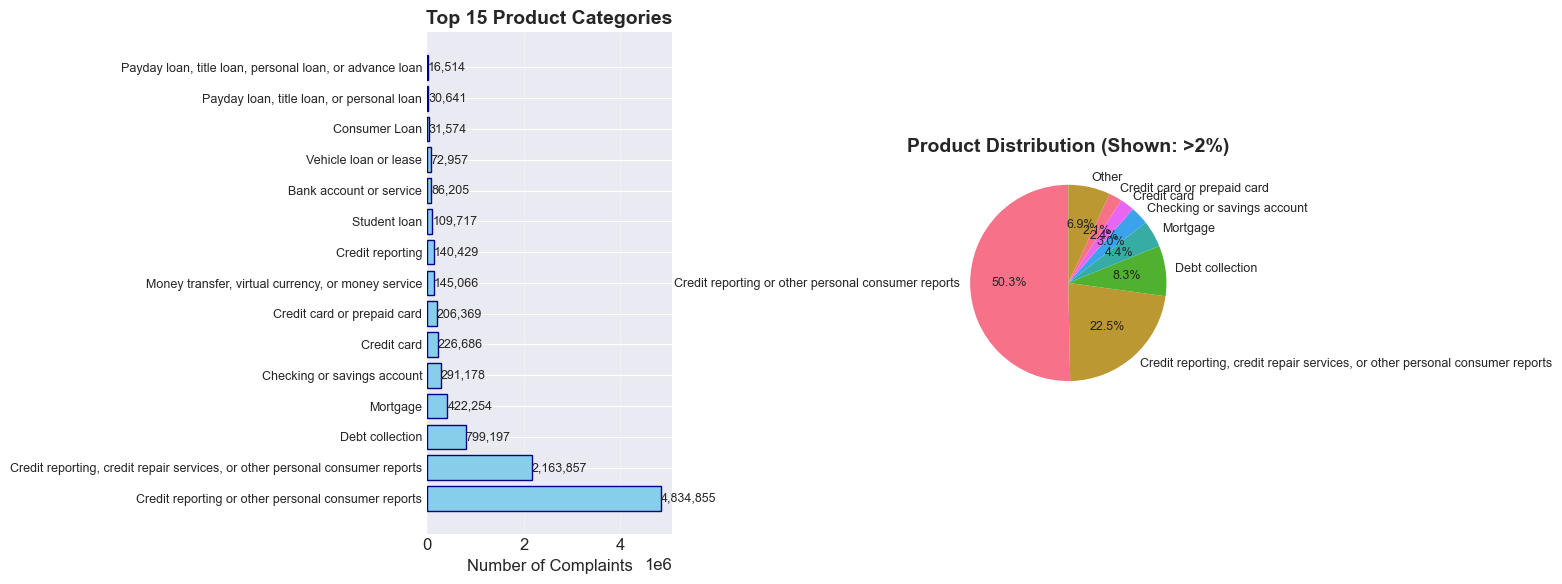

In [28]:
# Create visualization for product distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot - Top 15 products
top_products = product_counts.head(15)
axes[0].barh(range(len(top_products)), top_products.values, color='skyblue', edgecolor='navy')
axes[0].set_yticks(range(len(top_products)))
axes[0].set_yticklabels(top_products.index, fontsize=9)
axes[0].set_xlabel('Number of Complaints', fontsize=12)
axes[0].set_title('Top 15 Product Categories', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_products.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Pie chart
other_threshold = 0.02  # 2%
main_products = product_counts[product_counts / product_counts.sum() > other_threshold]
other_count = product_counts[product_counts / product_counts.sum() <= other_threshold].sum()

if other_count > 0:
    main_products['Other'] = other_count

axes[1].pie(main_products.values, labels=main_products.index, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Product Distribution (Shown: >2%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
# Filter for target products
# Define target products (exactly as they appear in your dataset)
target_products = [
    'Credit card',
    'Credit Card',
    'Personal loan',
    'Personal Loan',
    'Savings account',
    'Savings Account',
    'Money transfer',
    'Money Transfer'
]

# Create filter for target products (case-insensitive)
mask = df[product_col].str.lower().isin([p.lower() for p in target_products])
df_filtered = df[mask].copy()

print(f"\n Filtered dataset for target products:")
print(f"  Original records: {len(df):,}")
print(f"  Filtered records: {len(df_filtered):,}")

print(f"\n Product Distribution in Filtered Dataset:")
for product, count in df_filtered[product_col].value_counts().items():
    percentage = (count / len(df_filtered)) * 100
    print(f"  {product}: {count:,} ({percentage:.2f}%)")


 Filtered dataset for target products:
  Original records: 9,609,797
  Filtered records: 226,686

 Product Distribution in Filtered Dataset:
  Credit card: 226,686 (100.00%)


In [30]:
print("CONSUMER NARRATIVE ANALYSIS")


# We know the narrative column is 'Consumer complaint narrative'
narrative_col = 'Consumer complaint narrative'

print(f"Narrative column identified: '{narrative_col}'")

# Count complaints with narratives
has_narrative = df_filtered[narrative_col].notna()
has_non_empty = df_filtered[narrative_col].str.strip().ne('') & has_narrative

print(f"\n Narrative Availability:")
print(f"  Total complaints in filtered dataset: {len(df_filtered):,}")
print(f"  With narrative: {has_narrative.sum():,} ({has_narrative.sum()/len(df_filtered)*100:.2f}%)")
print(f"  With non-empty narrative: {has_non_empty.sum():,} ({has_non_empty.sum()/len(df_filtered)*100:.2f}%)")
print(f"  Without narrative: {(~has_narrative).sum():,} ({(~has_narrative).sum()/len(df_filtered)*100:.2f}%)")

# Calculate narrative lengths (in words)
df_filtered['word_count'] = df_filtered[narrative_col].fillna('').str.split().str.len()
df_filtered['char_count'] = df_filtered[narrative_col].fillna('').str.len()

# Remove empty narratives for length analysis
df_with_narrative = df_filtered[df_filtered['word_count'] > 0].copy()

if len(df_with_narrative) > 0:
    print(f"\n Narrative Length Statistics (Word Count):")
    print(f"  Mean: {df_with_narrative['word_count'].mean():.2f}")
    print(f"  Median: {df_with_narrative['word_count'].median():.2f}")
    print(f"  Std Dev: {df_with_narrative['word_count'].std():.2f}")
    print(f"  Min: {df_with_narrative['word_count'].min()}")
    print(f"  Max: {df_with_narrative['word_count'].max()}")
    print(f"  Q1: {df_with_narrative['word_count'].quantile(0.25):.2f}")
    print(f"  Q3: {df_with_narrative['word_count'].quantile(0.75):.2f}")
    
    # Identify very short and very long narratives
    very_short = df_with_narrative[df_with_narrative['word_count'] <= 10]
    very_long = df_with_narrative[df_with_narrative['word_count'] >= 500]
    
    print(f"\n Extreme Lengths:")
    print(f"  Very short (≤10 words): {len(very_short):,} ({len(very_short)/len(df_with_narrative)*100:.2f}%)")
    print(f"  Very long (≥500 words): {len(very_long):,} ({len(very_long)/len(df_with_narrative)*100:.2f}%)")
else:
    print("\n No non-empty narratives found in filtered dataset!")

CONSUMER NARRATIVE ANALYSIS
Narrative column identified: 'Consumer complaint narrative'

 Narrative Availability:
  Total complaints in filtered dataset: 226,686
  With narrative: 80,667 (35.59%)
  With non-empty narrative: 80,667 (35.59%)
  Without narrative: 146,019 (64.41%)

 Narrative Length Statistics (Word Count):
  Mean: 199.79
  Median: 141.00
  Std Dev: 223.18
  Min: 2
  Max: 6469
  Q1: 63.00
  Q3: 260.00

 Extreme Lengths:
  Very short (≤10 words): 435 (0.54%)
  Very long (≥500 words): 5,555 (6.89%)


In [33]:

print("CONSUMER NARRATIVE ANALYSIS")

# We know the narrative column is 'Consumer complaint narrative'
narrative_col = 'Consumer complaint narrative'

print(f" Narrative column identified: '{narrative_col}'")

# Count complaints with narratives
has_narrative = df_filtered[narrative_col].notna()
has_non_empty = df_filtered[narrative_col].str.strip().ne('') & has_narrative

print(f"\nNarrative Availability:")
print(f"  Total complaints in filtered dataset: {len(df_filtered):,}")
print(f"  With narrative: {has_narrative.sum():,} ({has_narrative.sum()/len(df_filtered)*100:.2f}%)")
print(f"  With non-empty narrative: {has_non_empty.sum():,} ({has_non_empty.sum()/len(df_filtered)*100:.2f}%)")
print(f"  Without narrative: {(~has_narrative).sum():,} ({(~has_narrative).sum()/len(df_filtered)*100:.2f}%)")

# Calculate narrative lengths (in words)
df_filtered['word_count'] = df_filtered[narrative_col].fillna('').str.split().str.len()
df_filtered['char_count'] = df_filtered[narrative_col].fillna('').str.len()

# Remove empty narratives for length analysis
df_with_narrative = df_filtered[df_filtered['word_count'] > 0].copy()

if len(df_with_narrative) > 0:
    print(f"\n Narrative Length Statistics (Word Count):")
    print(f"  Mean: {df_with_narrative['word_count'].mean():.2f}")
    print(f"  Median: {df_with_narrative['word_count'].median():.2f}")
    print(f"  Std Dev: {df_with_narrative['word_count'].std():.2f}")
    print(f"  Min: {df_with_narrative['word_count'].min()}")
    print(f"  Max: {df_with_narrative['word_count'].max()}")
    print(f"  Q1: {df_with_narrative['word_count'].quantile(0.25):.2f}")
    print(f"  Q3: {df_with_narrative['word_count'].quantile(0.75):.2f}")
    
    # Identify very short and very long narratives
    very_short = df_with_narrative[df_with_narrative['word_count'] <= 10]
    very_long = df_with_narrative[df_with_narrative['word_count'] >= 500]
    
    print(f"\nExtreme Lengths:")
    print(f"  Very short (≤10 words): {len(very_short):,} ({len(very_short)/len(df_with_narrative)*100:.2f}%)")
    print(f"  Very long (≥500 words): {len(very_long):,} ({len(very_long)/len(df_with_narrative)*100:.2f}%)")
else:
    print("\n No non-empty narratives found in filtered dataset!")

CONSUMER NARRATIVE ANALYSIS
 Narrative column identified: 'Consumer complaint narrative'

Narrative Availability:
  Total complaints in filtered dataset: 226,686
  With narrative: 80,667 (35.59%)
  With non-empty narrative: 80,667 (35.59%)
  Without narrative: 146,019 (64.41%)

 Narrative Length Statistics (Word Count):
  Mean: 199.79
  Median: 141.00
  Std Dev: 223.18
  Min: 2
  Max: 6469
  Q1: 63.00
  Q3: 260.00

Extreme Lengths:
  Very short (≤10 words): 435 (0.54%)
  Very long (≥500 words): 5,555 (6.89%)


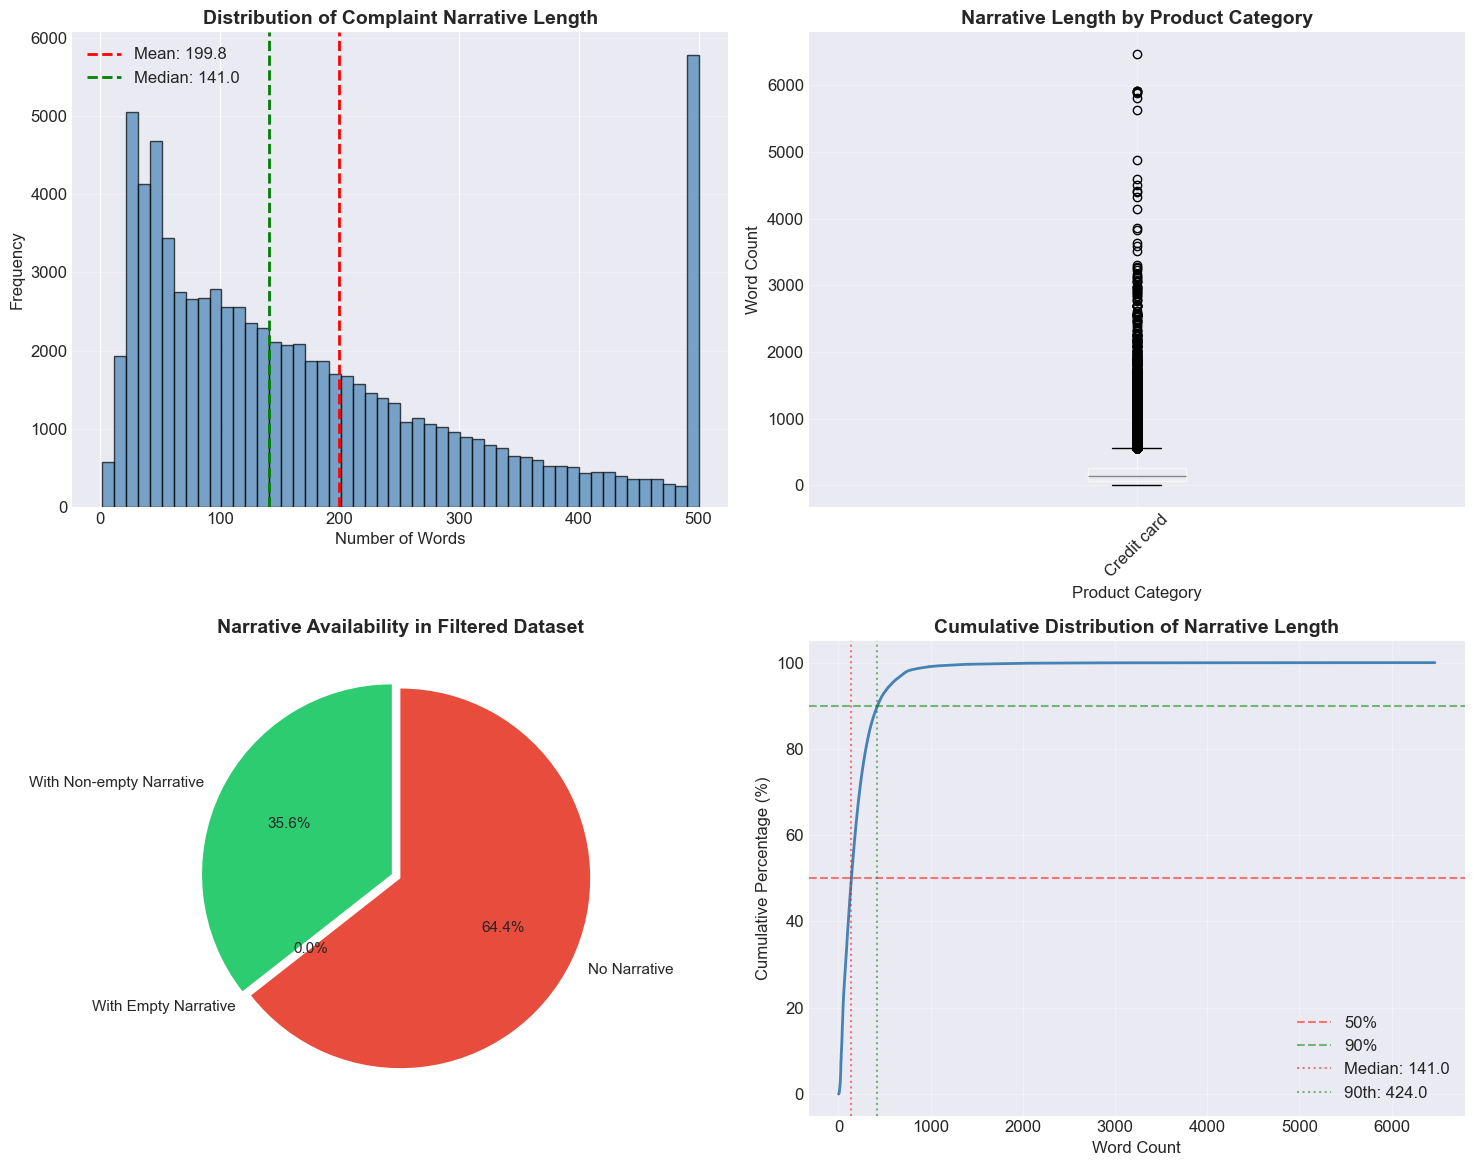

In [34]:
# Create visualizations for narrative analysis
if len(df_with_narrative) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram of word counts
    ax1 = axes[0, 0]
    word_counts = df_with_narrative['word_count'].copy()
    # Cap at 500 words for better visualization
    word_counts_capped = word_counts.copy()
    word_counts_capped[word_counts_capped > 500] = 500
    
    ax1.hist(word_counts_capped, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(word_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {word_counts.mean():.1f}')
    ax1.axvline(word_counts.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {word_counts.median():.1f}')
    ax1.set_xlabel('Number of Words', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Distribution of Complaint Narrative Length', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Boxplot by product category
    ax2 = axes[0, 1]
    # Get top products for clarity
    top_products = df_with_narrative[product_col].value_counts().head(8).index
    plot_data = df_with_narrative[df_with_narrative[product_col].isin(top_products)]
    
    # Create boxplot
    plot_data.boxplot(column='word_count', by=product_col, ax=ax2)
    ax2.set_title('Narrative Length by Product Category', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Product Category', fontsize=12)
    ax2.set_ylabel('Word Count', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(alpha=0.3)
    plt.suptitle('')  # Remove the automatic title
    
    # Narrative availability pie chart
    ax3 = axes[1, 0]
    narrative_status = [
        has_non_empty.sum(),
        has_narrative.sum() - has_non_empty.sum(),
        len(df_filtered) - has_narrative.sum()
    ]
    labels = ['With Non-empty Narrative', 'With Empty Narrative', 'No Narrative']
    colors = ['#2ecc71', '#f1c40f', '#e74c3c']
    explode = (0.05, 0, 0)
    ax3.pie(narrative_status, labels=labels, autopct='%1.1f%%', 
            colors=colors, explode=explode, startangle=90, textprops={'fontsize': 11})
    ax3.set_title('Narrative Availability in Filtered Dataset', fontsize=14, fontweight='bold')
    
    # Cumulative percentage of narratives by length
    ax4 = axes[1, 1]
    sorted_lengths = np.sort(word_counts)
    cumulative_percentage = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
    ax4.plot(sorted_lengths, cumulative_percentage, color='steelblue', linewidth=2)
    ax4.set_xlabel('Word Count', fontsize=12)
    ax4.set_ylabel('Cumulative Percentage (%)', fontsize=12)
    ax4.set_title('Cumulative Distribution of Narrative Length', fontsize=14, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    # Add reference lines
    ax4.axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
    ax4.axhline(90, color='green', linestyle='--', alpha=0.5, label='90%')
    ax4.axvline(word_counts.median(), color='red', linestyle=':', alpha=0.5, label=f'Median: {word_counts.median():.1f}')
    ax4.axvline(np.percentile(word_counts, 90), color='green', linestyle=':', alpha=0.5, label=f'90th: {np.percentile(word_counts, 90):.1f}')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

In [35]:

print("TEXT CLEANING AND PREPROCESSING")

# Function to clean text
def clean_text(text):

    if pd.isna(text) or text == '' or text == ' ':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Common boilerplate phrases to remove
    boilerplate_patterns = [
        r'i am writing to file a complaint about',
        r'i am writing to complain about',
        r'i am filing a complaint regarding',
        r'i wish to complain about',
        r'i want to complain about',
        r'i am submitting a complaint',
        r'this is a complaint about',
        r'i would like to complain about',
        r'i hereby file a complaint',
        r'please consider this a complaint',
        r'i am writing to express my dissatisfaction',
        r'i am writing to bring to your attention',
        r'i am contacting you to complain',
        r'i am writing this letter to complain',
        r'this complaint is regarding',
        r'this letter is to complain',
        
        # Common closings
        r'thank you for your attention to this matter',
        r'thank you for your consideration',
        r'i look forward to hearing from you',
        r'i look forward to your response',
        r'i await your response',
        r'please contact me at',
        r'please call me at',
        r'you can reach me at',
        r'sincerely,?',
        r'regards,?',
        r'respectfully,?',
        r'thank you,?',
        r'thanks,?',
        
        # Common filler phrases
        r'i have been a customer for',
        r'i have been with',
        r'i have been using',
        r'i have been a loyal customer',
        r'i am very disappointed',
        r'i am extremely dissatisfied',
    ]
    
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.MULTILINE)
    
    # Remove special characters but keep letters, numbers, spaces, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,?!]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

TEXT CLEANING AND PREPROCESSING


In [36]:
# Test the cleaning function on a sample
print("Testing cleaning function on sample narratives...")

# Get a sample of narratives
sample_narratives = df_filtered[df_filtered[narrative_col].notna()][narrative_col].head(3)

for i, text in enumerate(sample_narratives, 1):
    print(f"\nSample {i}:")
    print(f"Original ({len(str(text))} chars):")
    print(f"  {str(text)[:300]}..." if len(str(text)) > 300 else f"  {text}")
    print(f"Cleaned ({len(clean_text(text))} chars):")
    cleaned = clean_text(text)
    print(f"  {cleaned[:300]}..." if len(cleaned) > 300 else f"  {cleaned}")
    print("-" * 80)

Testing cleaning function on sample narratives...

Sample 1:
Original (488 chars):
  A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However...
Cleaned (487 chars):
  a xxxx xxxx card was opened under my name by a fraudster. i received a notice from xxxx that an account was just opened under my name. i reached out to xxxx xxxx to state that this activity was unauthorized and not me. xxxx xxxx confirmed this was fraudulent and immediately closed the card. however,...
--------------------------------------------------------------------------------

Sample 2:
Original (806 chars):
  Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have been calling n waitting for the check release the secured amount {$2

In [38]:
# Apply cleaning to all narratives
print("\n Applying cleaning to all narratives...")
df_filtered['cleaned_narrative'] = df_filtered[narrative_col].apply(clean_text)

# Calculate cleaned narrative lengths
df_filtered['cleaned_word_count'] = df_filtered['cleaned_narrative'].str.split().str.len()
df_filtered['cleaned_char_count'] = df_filtered['cleaned_narrative'].str.len()

# Statistics before and after cleaning
print(f"\n Cleaning Results:")
print(f"  Records with non-empty cleaned text: {(df_filtered['cleaned_word_count'] > 0).sum():,}")

# Only include records with non-empty cleaned text
df_with_cleaned = df_filtered[df_filtered['cleaned_word_count'] > 0].copy()

if len(df_with_cleaned) > 0:
    print(f"\nLength Statistics Comparison (for non-empty narratives):")
    print(f"  Original average word count: {df_with_cleaned['word_count'].mean():.2f}")
    print(f"  Cleaned average word count: {df_with_cleaned['cleaned_word_count'].mean():.2f}")
    print(f"  Average reduction: {((df_with_cleaned['word_count'].mean() - df_with_cleaned['cleaned_word_count'].mean()) / df_with_cleaned['word_count'].mean() * 100):.2f}%")
else:
    print("\n No non-empty cleaned narratives found!")


 Applying cleaning to all narratives...

 Cleaning Results:
  Records with non-empty cleaned text: 80,667

Length Statistics Comparison (for non-empty narratives):
  Original average word count: 199.79
  Cleaned average word count: 200.35
  Average reduction: -0.28%


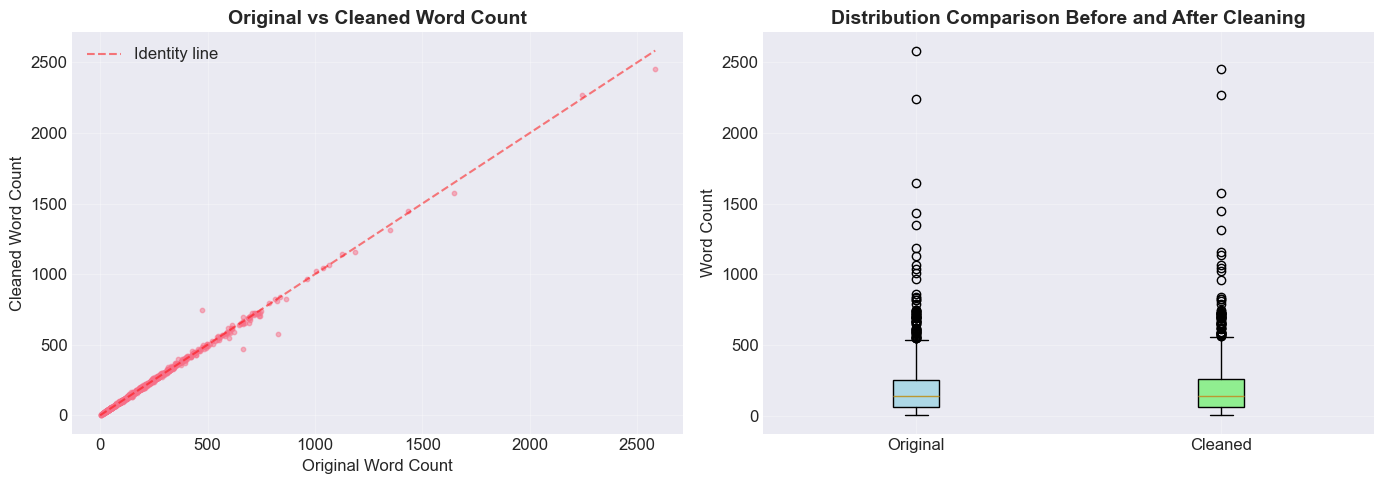

In [39]:
# Visualize cleaning impact
if len(df_with_cleaned) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot of original vs cleaned length
    ax1 = axes[0]
    # Sample for scatter plot (to avoid overcrowding)
    sample_for_scatter = df_with_cleaned.sample(min(1000, len(df_with_cleaned)), random_state=42)
    ax1.scatter(sample_for_scatter['word_count'], sample_for_scatter['cleaned_word_count'], 
                alpha=0.5, s=10)
    ax1.plot([0, sample_for_scatter['word_count'].max()], 
             [0, sample_for_scatter['word_count'].max()], 
             'r--', alpha=0.5, label='Identity line')
    ax1.set_xlabel('Original Word Count', fontsize=12)
    ax1.set_ylabel('Cleaned Word Count', fontsize=12)
    ax1.set_title('Original vs Cleaned Word Count', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Boxplot comparing distributions
    ax2 = axes[1]
    data_to_plot = [sample_for_scatter['word_count'], sample_for_scatter['cleaned_word_count']]
    bp = ax2.boxplot(data_to_plot, labels=['Original', 'Cleaned'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    ax2.set_ylabel('Word Count', fontsize=12)
    ax2.set_title('Distribution Comparison Before and After Cleaning', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [40]:

print("FINAL DATASET PREPARATION")


# Remove records with empty cleaned narratives
df_final = df_filtered[df_filtered['cleaned_narrative'].str.len() > 0].copy()

print(f"\n Final Dataset Summary:")
print(f"  Original dataset: {len(df):,} records")
print(f"  After product filtering: {len(df_filtered):,} records")
print(f"  After removing empty narratives: {len(df_final):,} records")
print(f"  Final retention rate: {len(df_final)/len(df)*100:.2f}%")

# Check product distribution in final dataset
print(f"\n Product Distribution in Final Dataset:")
for product, count in df_final[product_col].value_counts().items():
    percentage = (count / len(df_final)) * 100
    print(f"  {product}: {count:,} ({percentage:.2f}%)")

# Display sample of cleaned narratives
print(f"\n Sample of Cleaned Narratives:")
sample_texts = df_final[['Product', 'cleaned_narrative']].head(5)
for idx, row in sample_texts.iterrows():
    print(f"\nProduct: {row['Product']}")
    print(f"Text: {row['cleaned_narrative'][:200]}...")

FINAL DATASET PREPARATION

 Final Dataset Summary:
  Original dataset: 9,609,797 records
  After product filtering: 226,686 records
  After removing empty narratives: 80,667 records
  Final retention rate: 0.84%

 Product Distribution in Final Dataset:
  Credit card: 80,667 (100.00%)

 Sample of Cleaned Narratives:

Product: Credit card
Text: a xxxx xxxx card was opened under my name by a fraudster. i received a notice from xxxx that an account was just opened under my name. i reached out to xxxx xxxx to state that this activity was unauth...

Product: Credit card
Text: dear cfpb, i have a secured credit card with citibank which is changed to unsecured card and i have been calling n waitting for the check release the secured amount 2500.00 for rhat credit card. they ...

Product: Credit card
Text: i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, which meant my bills would be lowered, which meant i d have less use for my credit cards. so in or

In [41]:
# Save the cleaned and filtered dataset
output_path = '../data/filtered_complaints.csv'
# Create directory if it doesn't exist
import os
os.makedirs('../data', exist_ok=True)
df_final.to_csv(output_path, index=False)
print(f"\n Cleaned dataset saved to: {output_path}")

# Also save a sample for quick testing
sample_path = '../data/filtered_complaints_sample.csv'
df_final.sample(min(1000, len(df_final)), random_state=42).to_csv(sample_path, index=False)
print(f"Sample dataset saved to: {sample_path}")

# Display final dataset info
print(f"\nFinal Dataset Info:")
print(f"  Shape: {df_final.shape}")
print(f"  Columns: {df_final.columns.tolist()}")
print(f"\nMemory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


 Cleaned dataset saved to: ../data/filtered_complaints.csv
Sample dataset saved to: ../data/filtered_complaints_sample.csv

Final Dataset Info:
  Shape: (80667, 23)
  Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID', 'word_count', 'char_count', 'cleaned_narrative', 'cleaned_word_count', 'cleaned_char_count']

Memory usage: 267.18 MB
